In [488]:
! pip install "granite-tsfm[notebooks]==0.3.1"
! pip install gdown


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [489]:
import math
import os
import joblib

import numpy as np
import pandas as pd
import torch
import evaluate
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import Subset
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

from tsfm_public.models.tspulse import TSPulseForReconstruction
from tsfm_public.toolkit.time_series_preprocessor import (
    TimeSeriesPreprocessor,
    get_datasets,
)

## Load data from carOBD

In [490]:
path = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata" 
time_col = 'ENGINE_RUN_TINE ()'

df_list = []
for file in os.listdir(path):
  if file.endswith('.csv'):
    df = pd.read_csv(f'{path}/{file}', index_col=False)
    df['filename'] = file
    df_list.append(df)

print(f'{len(df_list)} files loaded out of {len([f for f in os.listdir(path) if f.endswith(".csv")])}')


129 files loaded out of 129


## Remove zero-variance columns

In [491]:
def remove_zero_variance_columns(df: pd.DataFrame) -> pd.DataFrame:
  """
  Compute std of each std-computable column (numeric only)
  """
  std_df = df.std(numeric_only=True)

  zero_variance_cols = std_df[std_df == 0].index.tolist()
  print(f'{len(zero_variance_cols)} columns with zero variance')

  if len(zero_variance_cols) > 0:
    df = df.drop(columns=zero_variance_cols)

  return df

## Handle missing Timestamps and duplicates

In [492]:
def mean_fill_missing_timestamps_and_remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
  """
  Remove duplicate timestamps by averaging all numeric columns for each unique timestamp.
  This preserves the overall statistics while removing duplicate entries.
  
  Note: The time column itself is not averaged (it becomes the group key).
  Only numeric columns are averaged when multiple rows share the same timestamp.
  """
  df = df.groupby(time_col, as_index=False).mean(numeric_only=True)
  return df

## Inject Anomalies

In [493]:
from typing import Tuple, Dict, Optional, List

def create_realistic_fault_data(
    normal_data: np.ndarray, 
    fault_percentage: float = 0.2,
    random_state: Optional[int] = None,
    fault_types: Optional[List[str]] = None
) -> Tuple[np.ndarray, np.ndarray, Dict]:
    if fault_types is None:
        fault_types = ['coolant_bias', 'coolant_drift', 'coolant_stuck', 'rpm_bias', 'multi_sensor']
    
    if random_state is not None:
        np.random.seed(random_state)
    
    n_samples = len(normal_data)
    n_faults = int(n_samples * fault_percentage)
    
    fault_labels = np.zeros(n_samples, dtype=int)
    fault_indices = np.random.choice(n_samples, n_faults, replace=False)
    fault_labels[fault_indices] = 1
    fault_features = normal_data.copy()
    
    fault_type_list = [None] * n_samples
    original_values = [[] for _ in range(n_samples)]
    modified_values = [[] for _ in range(n_samples)]
    
    for idx in fault_indices:
        fault_type = np.random.choice(fault_types)
        fault_type_list[idx] = fault_type
        
        if fault_type == 'coolant_bias':
            bias_amount = np.random.uniform(40, 80) * np.random.choice([-1, 1])
            original_val = fault_features[idx, 0]
            fault_features[idx, 0] += bias_amount
            original_values[idx].append(original_val)
            modified_values[idx].append(fault_features[idx, 0])
        
        elif fault_type == 'coolant_drift':
            drift_factor = np.random.uniform(0.6, 1.4)
            original_val = fault_features[idx, 0]
            fault_features[idx, 0] *= drift_factor
            original_values[idx].append(original_val)
            modified_values[idx].append(fault_features[idx, 0])
            
            if fault_features.shape[1] > 1:
                rpm_factor = np.random.uniform(0.7, 1.3)
                original_rpm = fault_features[idx, 1]
                fault_features[idx, 1] *= rpm_factor
                original_values[idx].append(original_rpm)
                modified_values[idx].append(fault_features[idx, 1])
        
        elif fault_type == 'coolant_stuck':
            stuck_temp = np.random.uniform(10, 150)
            original_val = fault_features[idx, 0]
            fault_features[idx, 0] = stuck_temp
            original_values[idx].append(original_val)
            modified_values[idx].append(stuck_temp)
        
        elif fault_type == 'rpm_bias':
            rpm_bias = np.random.uniform(300, 1000) * np.random.choice([-1, 1])
            if fault_features.shape[1] > 1:
                original_rpm = fault_features[idx, 1]
                fault_features[idx, 1] += rpm_bias
                original_values[idx].append(original_rpm)
                modified_values[idx].append(fault_features[idx, 1])
        
        elif fault_type == 'multi_sensor':
            degradation_factor = np.random.uniform(0.5, 1.5)
            original_vals_copy = fault_features[idx].copy()
            fault_features[idx] *= degradation_factor
            noise_level = np.random.uniform(0.15, 0.3)
            fault_features[idx] += np.random.normal(0, noise_level, fault_features.shape[1])
            
            for col_idx in range(fault_features.shape[1]):
                original_values[idx].append(original_vals_copy[col_idx])
                modified_values[idx].append(fault_features[idx, col_idx])
    
    fault_info = {
        'fault_types': fault_type_list,
        'original_values': original_values,
        'modified_values': modified_values,
        'n_faults': n_faults,
        'fault_percentage': fault_percentage
    }
    
    return fault_features, fault_labels, fault_info

## Process Data

In [494]:
target_columns = [
    'COOLANT_TEMPERATURE ()',
    'ENGINE_RPM ()',
    'VEHICLE_SPEED ()',
    'THROTTLE ()',
    'ENGINE_LOAD ()',
    'INTAKE_MANIFOLD_PRESSURE ()',
]

print("Processing all files and combining into single DataFrame...")
dfs = []
skipped_files = []

for drive_idx, df in enumerate(df_list):
    df_clean = mean_fill_missing_timestamps_and_remove_duplicates(df)
    
    missing_cols = [col for col in target_columns if col not in df_clean.columns]
    if missing_cols:
        print(f"⚠️  File {drive_idx} missing columns: {missing_cols}")
        skipped_files.append(drive_idx)
        continue
    
    if time_col not in df_clean.columns:
        print(f"⚠️  File {drive_idx} missing timestamp column: {time_col}")
        skipped_files.append(drive_idx)
        continue
    
    # Add drive_id to identify each time series
    df_clean['drive_id'] = drive_idx

    required_cols = [time_col, 'drive_id'] + target_columns
    df_clean = df_clean[required_cols].copy()
    
    if not pd.api.types.is_numeric_dtype(df_clean[time_col]):
        df_clean[time_col] = pd.to_numeric(df_clean[time_col], errors='coerce')
    
    df_clean = df_clean.dropna(subset=[time_col] + target_columns)
    
    if len(df_clean) == 0:
        print(f"⚠️  File {drive_idx} has no valid data after cleaning")
        skipped_files.append(drive_idx)
        continue
    
    dfs.append(df_clean)
    print(f"✓ File {drive_idx}: {len(df_clean)} samples")

# Combine all dataframes
if len(dfs) == 0:
    raise ValueError("No valid data files found!")

data = pd.concat(dfs, ignore_index=True)

print(f"\n{'='*60}")
print(f"Data Summary:")
print(f"{'='*60}")
print(f"Total files processed: {len(dfs)}")
print(f"Skipped files: {len(skipped_files)}")
print(f"Total rows: {len(data):,}")
print(f"Unique drives: {data['drive_id'].nunique()}")
print(f"Columns: {list(data.columns)}")
print(f"\nData shape: {data.shape}")

Processing all files and combining into single DataFrame...
✓ File 0: 617 samples
✓ File 1: 722 samples
✓ File 2: 512 samples
✓ File 3: 1111 samples
✓ File 4: 350 samples
✓ File 5: 397 samples
✓ File 6: 619 samples
✓ File 7: 626 samples
✓ File 8: 957 samples
✓ File 9: 349 samples
✓ File 10: 504 samples
✓ File 11: 265 samples
✓ File 12: 368 samples
✓ File 13: 1041 samples
✓ File 14: 1482 samples
✓ File 15: 343 samples
✓ File 16: 837 samples
✓ File 17: 640 samples
✓ File 18: 1099 samples
✓ File 19: 2039 samples
✓ File 20: 576 samples
✓ File 21: 1029 samples
✓ File 22: 346 samples
✓ File 23: 885 samples
✓ File 24: 297 samples
✓ File 25: 215 samples
✓ File 26: 656 samples
✓ File 27: 1176 samples
✓ File 28: 1646 samples
✓ File 29: 305 samples
✓ File 30: 198 samples
✓ File 31: 516 samples
✓ File 32: 328 samples
✓ File 33: 762 samples
✓ File 34: 311 samples
✓ File 35: 519 samples
✓ File 36: 1259 samples
✓ File 37: 903 samples
✓ File 38: 1591 samples
✓ File 39: 755 samples
✓ File 40: 474 sampl

In [495]:
context_length = 512
prediction_length = 16  # anomaly detection

tsp = TimeSeriesPreprocessor(
    timestamp_column=time_col,
    id_columns=['drive_id'],
    target_columns=target_columns,
    control_columns=[],  # Add extra features here if needed
    context_length=context_length,
    prediction_length=prediction_length,
    scaling=True,
    scaling_type="standard"
)

print("TimeSeriesPreprocessor configured:")
print(f"  Context length: {context_length}")
print(f"  Prediction length: {prediction_length}")
print(f"  Target columns: {len(target_columns)}")
print(f"  Scaling: {tsp.scaling} ({tsp.scaling_type})")

TimeSeriesPreprocessor configured:
  Context length: 512
  Prediction length: 16
  Target columns: 6
  Scaling: True (standard)


In [496]:

split_config = {"train": 0.7, "test": 0.2}

dset_train, dset_val, dset_test = get_datasets(
    tsp,
    data,
    split_config=split_config,
)

print(f"Train: {len(dset_train)}, Val: {len(dset_val)}, Test: {len(dset_test)}")

joblib.dump(tsp, "./tsp_preprocessor.joblib")
    

Train: 8254, Val: 3488, Test: 9232


['./tsp_preprocessor.joblib']

## Metrics

In [497]:
from evaluate import load

metric = load("f1")

## Model Init

In [499]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TSPulseForReconstruction.from_pretrained(
    "ibm-granite/granite-timeseries-tspulse-r1",
    revision="main",
    num_input_channels=tsp.num_input_channels
)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
num_epochs = 20

## Data Split

In [500]:
## Verify Dataset Structure

print(f"Train dataset: {len(dset_train)} samples")
print(f"Val dataset: {len(dset_val)} samples")
print(f"Test dataset: {len(dset_test)} samples")

# Verify the structure matches what the model expects
sample = dset_train[0]
print(f"\nSample keys: {sample.keys()}")
print(f"past_values shape: {sample['past_values'].shape}")
print(f"past_observed_mask shape: {sample['past_observed_mask'].shape}")

if 'id' in sample and 'timestamp' in sample:
    train_samples = [(dset_train[i]['id'], dset_train[i]['timestamp']) for i in range(len(dset_train))]
    val_samples = [(dset_val[i]['id'], dset_val[i]['timestamp']) for i in range(len(dset_val))]
    test_samples = [(dset_test[i]['id'], dset_test[i]['timestamp']) for i in range(len(dset_test))]
    
    train_set = set(train_samples)
    val_set = set(val_samples)
    test_set = set(test_samples)
    
    train_drive_ids = set([s[0] for s in train_samples])
    val_drive_ids = set([s[0] for s in val_samples])
    test_drive_ids = set([s[0] for s in test_samples])
    
    print(f"Unique drive_ids - Train: {len(train_drive_ids)}, Val: {len(val_drive_ids)}, Test: {len(test_drive_ids)}")
    print(f"Overlapping drive_ids - Train/Val: {len(train_drive_ids & val_drive_ids)}, Train/Test: {len(train_drive_ids & test_drive_ids)}, Val/Test: {len(val_drive_ids & test_drive_ids)}")
    print("(Same drive_id in multiple splits is expected with temporal splitting)")
    
    assert len(train_set & val_set) == 0, "❌ Data leakage: same (drive_id, timestamp) in train and val!"
    assert len(train_set & test_set) == 0, "❌ Data leakage: same (drive_id, timestamp) in train and test!"
    assert len(val_set & test_set) == 0, "❌ Data leakage: same (drive_id, timestamp) in val and test!"
    print("✓ No data leakage - no (drive_id, timestamp) combinations appear in multiple splits")
else:
    print("⚠️  id or timestamp not found in dataset - cannot verify data leakage")


Train dataset: 8254 samples
Val dataset: 3488 samples
Test dataset: 9232 samples

Sample keys: dict_keys(['past_values', 'future_values', 'past_observed_mask', 'future_observed_mask', 'timestamp', 'id'])
past_values shape: torch.Size([512, 6])
past_observed_mask shape: torch.Size([512, 6])


Unique drive_ids - Train: 129, Val: 99, Test: 129
Overlapping drive_ids - Train/Val: 99, Train/Test: 129, Val/Test: 99
(Same drive_id in multiple splits is expected with temporal splitting)
✓ No data leakage - no (drive_id, timestamp) combinations appear in multiple splits


## Train


In [502]:
from torch.utils.data import DataLoader
from transformers import default_data_collator
import torch

set_seed(42)

train_loader = DataLoader(
    dset_train,
    batch_size=64,
    shuffle=True,
    collate_fn=default_data_collator,
)

val_loader = DataLoader(
    dset_val,
    batch_size=64,
    shuffle=False,
    collate_fn=default_data_collator,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
num_epochs = 20

best_val_loss = float("inf")
best_state_dict = None

for epoch in range(num_epochs):
    # -------------------------
    # Train
    # -------------------------
    model.train()
    train_loss = 0.0
    n_train_batches = 0

    for batch in train_loader:
        past_values = batch["past_values"].to(device)              # (B, context_length, C)
        past_observed_mask = batch["past_observed_mask"].to(device)

        optimizer.zero_grad()

        # TSPulseForReconstruction returns a loss
        outputs = model(
            past_values=past_values,
            past_observed_mask=past_observed_mask,
            return_loss=True,
        )
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        n_train_batches += 1

    avg_train_loss = train_loss / max(n_train_batches, 1)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()
    val_loss = 0.0
    n_val_batches = 0

    with torch.no_grad():
        for batch in val_loader:
            past_values = batch["past_values"].to(device)
            past_observed_mask = batch["past_observed_mask"].to(device)

            outputs = model(
                past_values=past_values,
                past_observed_mask=past_observed_mask,
                return_loss=True,
            )
            loss = outputs.loss

            val_loss += loss.item()
            n_val_batches += 1

    avg_val_loss = val_loss / max(n_val_batches, 1)

    print(f"Epoch {epoch+1}/{num_epochs} | train_loss={avg_train_loss:.4f} | val_loss={avg_val_loss:.4f}")

    # Save best model in memory
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# Load best weights back into the model (if any)
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    model.to(device)
    print(f"\nLoaded best model with val_loss={best_val_loss:.4f}")


Epoch 1/20 | train_loss=1.0906 | val_loss=1.1301
Epoch 2/20 | train_loss=1.0783 | val_loss=1.1295
Epoch 3/20 | train_loss=1.0749 | val_loss=1.1178
Epoch 4/20 | train_loss=1.0686 | val_loss=1.1128
Epoch 5/20 | train_loss=1.0693 | val_loss=1.1070
Epoch 6/20 | train_loss=1.0676 | val_loss=1.1141
Epoch 7/20 | train_loss=1.0657 | val_loss=1.1046
Epoch 8/20 | train_loss=1.0620 | val_loss=1.1046
Epoch 9/20 | train_loss=1.0642 | val_loss=1.1121
Epoch 10/20 | train_loss=1.0628 | val_loss=1.1044
Epoch 11/20 | train_loss=1.0578 | val_loss=1.1061
Epoch 12/20 | train_loss=1.0579 | val_loss=1.1080
Epoch 13/20 | train_loss=1.0622 | val_loss=1.1074
Epoch 14/20 | train_loss=1.0591 | val_loss=1.1020
Epoch 15/20 | train_loss=1.0578 | val_loss=1.1168
Epoch 16/20 | train_loss=1.0564 | val_loss=1.1091
Epoch 17/20 | train_loss=1.0564 | val_loss=1.1046
Epoch 18/20 | train_loss=1.0519 | val_loss=1.1095
Epoch 19/20 | train_loss=1.0544 | val_loss=1.1085
Epoch 20/20 | train_loss=1.0504 | val_loss=1.1038

Loaded b

In [504]:
# Take one batch from the test loader
from torch.utils.data import DataLoader
from transformers import default_data_collator
import torch

test_loader = DataLoader(
    dset_test,
    batch_size=4,
    shuffle=False,
    collate_fn=default_data_collator,
)

batch = next(iter(test_loader))
past_values = batch["past_values"].to(device)
past_observed_mask = batch["past_observed_mask"].to(device)

model.eval()
with torch.no_grad():
    outputs = model(
        past_values=past_values,
        past_observed_mask=past_observed_mask,
        return_loss=False,
    )

print("Type:", type(outputs))
print("Dir:", dir(outputs))
try:
    print("As dict:", outputs.to_dict())
except Exception:
    pass


Type: <class 'tsfm_public.models.tspulse.modeling_tspulse.TSPulseForReconstructionOutput'>
Dir: ['__annotations__', '__class__', '__class_getitem__', '__contains__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__ior__', '__iter__', '__le__', '__len__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__or__', '__post_init__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__ror__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', 'backbone_hidden_state', 'clear', 'copy', 'decoder_hidden_state', 'fft_loss', 'fft_mask', 'fft_prob_loss', 'fft_reconstruction_outputs', 'fft_softmax_preds', 'forecast_loss', 'forecast_output', 'fromkeys', 'future_values', 'get', 'items', 'keys', 'loc', 'loss', 'mask', 'masked_past_values', 'masked_reconstruction_loss

In [507]:
# %% Point-wise anomaly scores from TSPulse R1

from torch.utils.data import DataLoader
from transformers import default_data_collator
import torch
import numpy as np

model.eval()

test_loader = DataLoader(
    dset_test,
    batch_size=32,
    shuffle=False,
    collate_fn=default_data_collator,
)

coolant_idx = target_columns.index("COOLANT_TEMPERATURE ()")

all_point_scores_fused = []      # (B, T_ctx) fused multi-head score
all_point_scores_time = []       # (B, T_ctx) time-head only
all_coolant_point_scores = []    # (B, T_ctx) coolant-only time-head
all_labels = []                  # optional, if you have per-window labels

with torch.no_grad():
    for batch in test_loader:
        past_values = batch["past_values"].to(device)                # (B, T_ctx, C)
        past_observed_mask = batch["past_observed_mask"].to(device)

        # If your preprocessor produced future_values, use them; else set None
        future_values = batch.get("future_values", None)
        if future_values is not None:
            future_values = future_values.to(device)                 # (B, T_pred, C)

        outputs = model(
            past_values=past_values,
            past_observed_mask=past_observed_mask,
            future_values=future_values,
            return_loss=False,
        )

        # 1) Time-domain reconstruction
        time_recon = outputs.reconstruction_outputs                 # (B, T_total, C)
        if time_recon.shape[1] != past_values.shape[1]:
            time_recon = time_recon[:, :past_values.shape[1], :]

        time_sq_err = (time_recon - past_values) ** 2               # (B, T_ctx, C)
        # per-timestep, averaged over channels
        time_err_t = time_sq_err.mean(dim=2)                        # (B, T_ctx)

        # 2) Frequency-domain reconstruction (reconstructed time signal from FFT)
        fft_recon = outputs.reconstructed_ts_from_fft               # (B, T_total, C)
        if fft_recon.shape[1] != past_values.shape[1]:
            fft_recon = fft_recon[:, :past_values.shape[1], :]

        fft_sq_err = (fft_recon - past_values) ** 2                 # (B, T_ctx, C)
        fft_err_t = fft_sq_err.mean(dim=2)                          # (B, T_ctx)

        # 3) Short-horizon forecast error (if available)
        forecast_err_t = None
        if future_values is not None and outputs.forecast_output is not None:
            forecast = outputs.forecast_output                      # (B, T_pred, C)
            T_pred = min(forecast.shape[1], future_values.shape[1])
            forecast_sq_err = (forecast[:, :T_pred, :]
                               - future_values[:, :T_pred, :]) ** 2  # (B, T_pred, C)
            forecast_err_t = forecast_sq_err.mean(dim=2)            # (B, T_pred)

            # Pad / tile forecast_err_t to length T_ctx if you want one score per past timestep
            if forecast_err_t.shape[1] < past_values.shape[1]:
                pad_len = past_values.shape[1] - forecast_err_t.shape[1]
                forecast_err_t = torch.nn.functional.pad(
                    forecast_err_t,
                    pad=(0, pad_len),
                    mode="replicate",
                )

        # Multi-head triangulation: fused per-timestep anomaly score
        if forecast_err_t is not None:
            stacked = torch.stack([time_err_t, fft_err_t, forecast_err_t], dim=2)  # (B, T_ctx, 3)
        else:
            stacked = torch.stack([time_err_t, fft_err_t], dim=2)                  # (B, T_ctx, 2)

        fused_err_t = torch.max(stacked, dim=2).values                              # (B, T_ctx)

        # Coolant-only per-timestep error (for your plots)
        coolant_time_sq = time_sq_err[:, :, coolant_idx]                            # (B, T_ctx)
        coolant_err_t = coolant_time_sq                                             # already per-timestep

        all_point_scores_fused.append(fused_err_t.cpu().numpy())
        all_point_scores_time.append(time_err_t.cpu().numpy())
        all_coolant_point_scores.append(coolant_err_t.cpu().numpy())

        # If you have per-window labels, store them (one label per window)
        if "labels" in batch:
            all_labels.append(batch["labels"].cpu().numpy())

point_scores_fused   = np.concatenate(all_point_scores_fused, axis=0)    # (N_windows, T_ctx)
point_scores_time    = np.concatenate(all_point_scores_time, axis=0)
coolant_point_scores = np.concatenate(all_coolant_point_scores, axis=0)
true_labels_windows  = np.concatenate(all_labels, axis=0) if all_labels else None
window_scores_fused   = point_scores_fused.max(axis=1)      # (N_windows,)
window_scores_coolant = coolant_point_scores.max(axis=1)    # (N_windows,)


print("Fused per-point scores shape:", point_scores_fused.shape)         # (N, T_ctx)
print("Coolant per-point scores shape:", coolant_point_scores.shape)


Fused per-point scores shape: (9232, 512)
Coolant per-point scores shape: (9232, 512)


In [509]:
import matplotlib.pyplot as plt
import numpy as np

def plot_channel_with_anomalies(
    results: pd.DataFrame,
    timestamp_column: str,
    value_column: str,
    anomaly_scores: np.ndarray,
    threshold: float,
    title: str = None,
):
    """
    results: DataFrame with time + sensor values
    timestamp_column: e.g. time_col
    value_column:     e.g. 'COOLANT_TEMPERATURE ()'
    anomaly_scores:   1D array, same length as results, point-wise score
    threshold:        scalar, points >= threshold are anomalies
    """
    t = results[timestamp_column].values
    y = results[value_column].values
    anomalies = anomaly_scores >= threshold

    plt.figure(figsize=(14, 4))
    plt.plot(t, y, color="steelblue", linewidth=1.5, label=value_column)
    plt.scatter(
        t[anomalies],
        y[anomalies],
        color="red",
        s=40,
        marker="x",
        label="Anomaly",
        zorder=5,
    )
    plt.xlabel("Time")
    plt.ylabel(value_column)
    plt.title(title or f"{value_column} with anomaly points")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


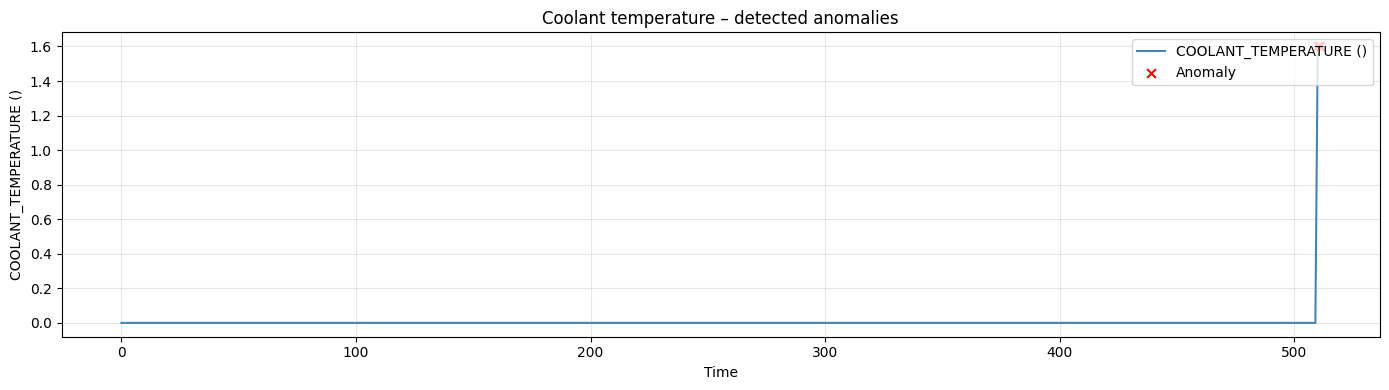

In [512]:
k = 0
sample = dset_test[k]

vals = sample["past_values"]                    # (T_ctx, C)
T_ctx = vals.shape[0]

# Simple x-axis: timestep index
ts = np.arange(T_ctx)

results = pd.DataFrame(vals, columns=target_columns)
results[time_col] = ts

anomaly_scores = coolant_point_scores[k]        # or point_scores_fused[k]

# Better: reuse your window-level optimal_threshold or tune from labels;
# as a quick start:
threshold = np.mean(anomaly_scores) + 2 * np.std(anomaly_scores)

plot_channel_with_anomalies(
    results=results,
    timestamp_column=time_col,
    value_column="COOLANT_TEMPERATURE ()",
    anomaly_scores=anomaly_scores,
    threshold=threshold,
    title="Coolant temperature – detected anomalies",
)

